# Regressão com Linearização
## Crescimento de Fundo de Investimento (Juros Compostos)

Neste notebook, trabalharemos com dados que seguem um comportamento **não linear** — especificamente, o crescimento exponencial de um investimento ao longo do tempo.

Veremos como **linearizar** a relação para aplicar regressão linear e depois recuperar os parâmetros originais.

## Conceito: Linearização de Funções Não Lineares

Nem todas as relações entre variáveis são lineares. Porém, algumas funções não lineares podem ser **transformadas** em lineares por meio de operações matemáticas.

### O Caso dos Juros Compostos

O valor de um investimento com juros compostos segue a fórmula:

$$V(t) = V_0 \cdot (1 + r)^t$$

onde:
- $V(t)$: valor do investimento no mês $t$
- $V_0$: valor inicial investido
- $r$: taxa de retorno mensal
- $t$: tempo em meses

### Aplicando o Logaritmo Natural

Ao aplicar $\ln$ em ambos os lados:

$$\ln(V) = \ln(V_0) + t \cdot \ln(1 + r)$$

Definindo:
- $Y = \ln(V)$
- $A = \ln(V_0)$ → intercepto
- $B = \ln(1 + r)$ → coeficiente angular

Obtemos a forma linear:

$$Y = A + B \cdot t$$

Após obter $A$ e $B$ pela regressão linear, recuperamos os parâmetros originais:
- $V_0 = e^A$
- $r = e^B - 1$

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')

## 2. Carregamento dos Dados

O dataset contém o valor mensal de um fundo de investimento ao longo de 120 meses (10 anos).

In [2]:
df = pd.read_csv('dados_investimento.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

Dimensões: 120 linhas × 2 colunas


,meses,valor_investimento
0,1,9749.41
1,2,10192.76
2,3,10426.76
3,4,10050.10
4,5,10549.55
5,6,11118.50
6,7,10862.51
7,8,11081.66
8,9,10086.14
9,10,11504.12


In [3]:
df.describe().round(2)

,meses,valor_investimento
count,120.00,120.00
mean,60.50,18713.84
std,34.79,6183.59
min,1.00,9749.41
25%,30.75,13494.13
50%,60.50,17570.38
75%,90.25,23505.92
max,120.00,31955.84


## 3. Visualização dos Dados Originais

Observe que a relação entre o tempo e o valor do investimento **não é linear** — o crescimento acelera ao longo do tempo (comportamento exponencial).

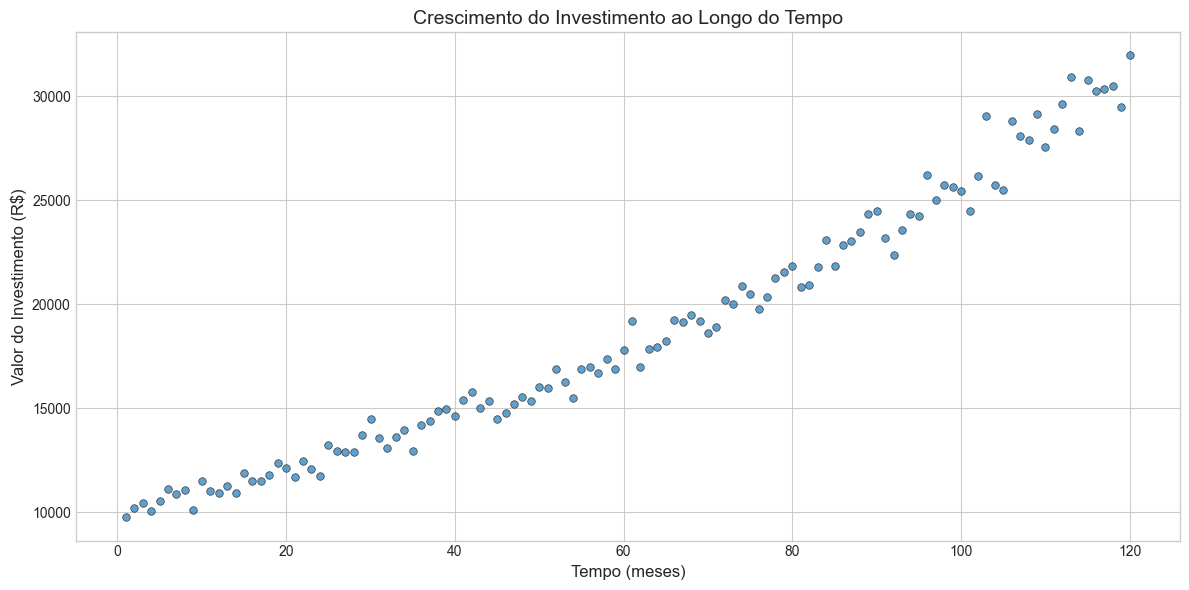

In [4]:
plt.figure(figsize=(12, 6))
plt.scatter(df['meses'], df['valor_investimento'], alpha=0.7, s=30, edgecolors='k', linewidths=0.5)
plt.xlabel('Tempo (meses)', fontsize=12)
plt.ylabel('Valor do Investimento (R$)', fontsize=12)
plt.title('Crescimento do Investimento ao Longo do Tempo', fontsize=14)
plt.tight_layout()
plt.show()

Se tentássemos ajustar uma reta diretamente a esses dados, o resultado seria ruim. Vamos demonstrar:

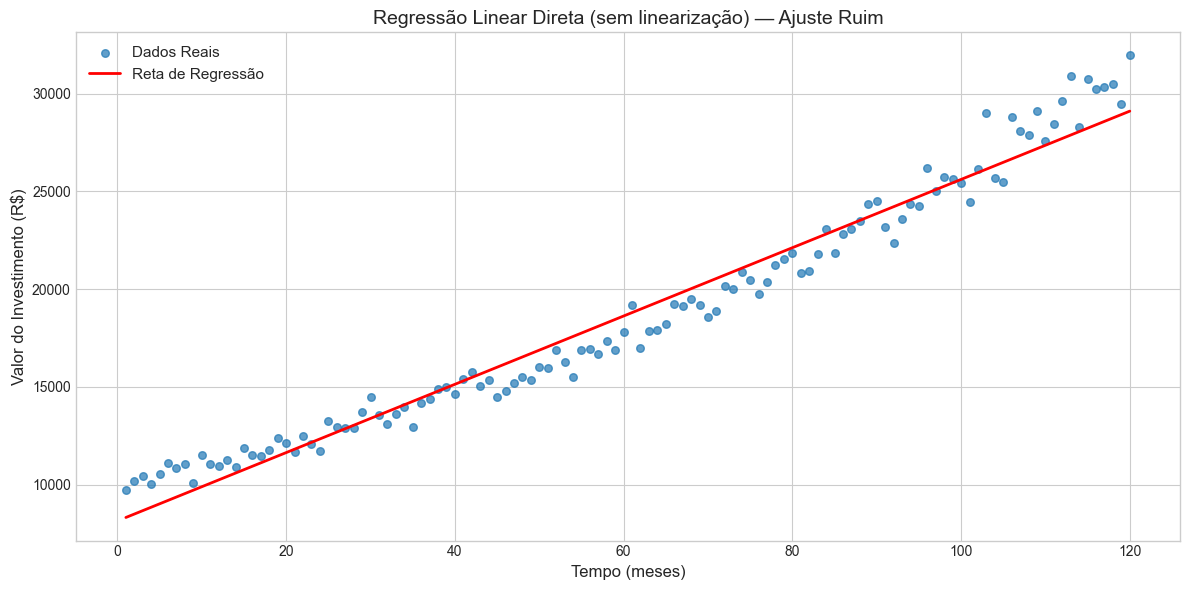

R² da regressão direta (sem transformação): 0.9656


In [5]:
# Regressão linear direta (sem transformação)
X_direto = df[['meses']]
y_direto = df['valor_investimento']

modelo_direto = LinearRegression()
modelo_direto.fit(X_direto, y_direto)
y_pred_direto = modelo_direto.predict(X_direto)

plt.figure(figsize=(12, 6))
plt.scatter(df['meses'], df['valor_investimento'], alpha=0.7, s=30, label='Dados Reais')
plt.plot(df['meses'], y_pred_direto, color='red', linewidth=2, label='Reta de Regressão')
plt.xlabel('Tempo (meses)', fontsize=12)
plt.ylabel('Valor do Investimento (R$)', fontsize=12)
plt.title('Regressão Linear Direta (sem linearização) — Ajuste Ruim', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

r2_direto = r2_score(y_direto, y_pred_direto)
print(f'R² da regressão direta (sem transformação): {r2_direto:.4f}')

## 4. Transformação Logarítmica

Agora aplicamos o logaritmo natural no valor do investimento para linearizar a relação.

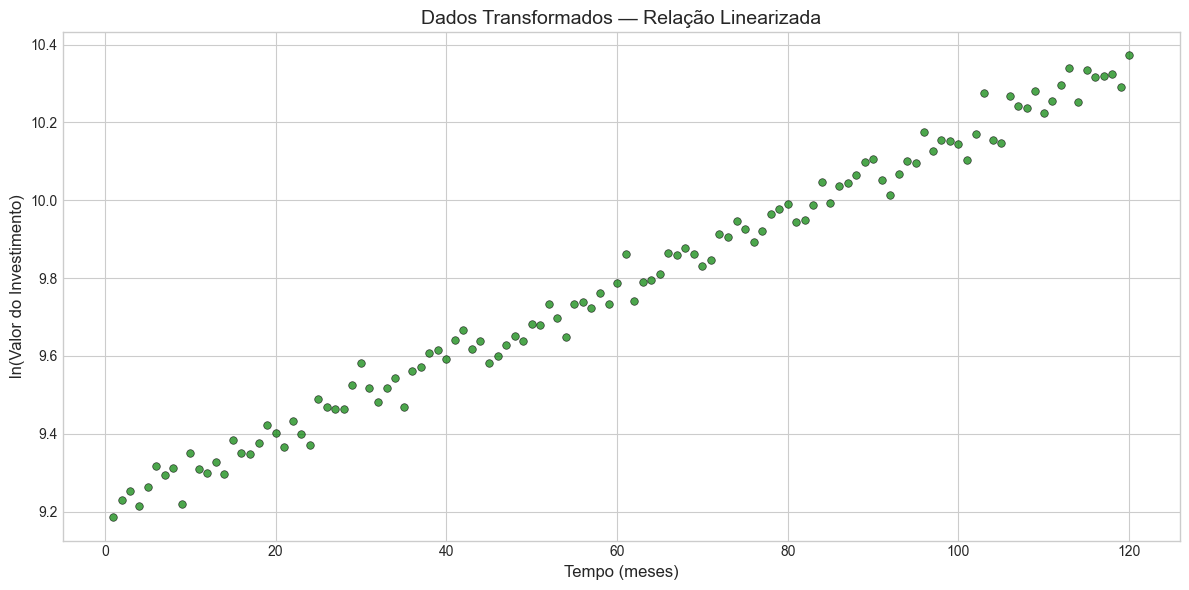

In [6]:
df['ln_valor'] = np.log(df['valor_investimento'])

plt.figure(figsize=(12, 6))
plt.scatter(df['meses'], df['ln_valor'], alpha=0.7, s=30, color='green', edgecolors='k', linewidths=0.5)
plt.xlabel('Tempo (meses)', fontsize=12)
plt.ylabel('ln(Valor do Investimento)', fontsize=12)
plt.title('Dados Transformados — Relação Linearizada', fontsize=14)
plt.tight_layout()
plt.show()

A relação agora é claramente linear.

## 5. Regressão Linear nos Dados Transformados

In [7]:
X = df[['meses']]
y_log = df['ln_valor']

modelo_log = LinearRegression()
modelo_log.fit(X, y_log)

A = modelo_log.intercept_
B = modelo_log.coef_[0]

print(f'Intercepto (A = ln(V₀)):       {A:.6f}')
print(f'Coef. angular (B = ln(1 + r)):  {B:.6f}')

Intercepto (A = ln(V₀)):       9.206541
Coef. angular (B = ln(1 + r)):  0.009521


## 6. Recuperação dos Parâmetros Originais

A partir dos coeficientes da regressão linear, recuperamos $V_0$ e $r$:

In [8]:
V0_estimado = np.exp(A)
r_mensal_estimado = np.exp(B) - 1
r_anual_estimado = (1 + r_mensal_estimado) ** 12 - 1

print(f'Valor inicial estimado (V₀):     R$ {V0_estimado:,.2f}')
print(f'Taxa mensal estimada (r):         {r_mensal_estimado:.6f} ({r_mensal_estimado*100:.4f}%)')
print(f'Taxa anual estimada:              {r_anual_estimado:.4f} ({r_anual_estimado*100:.2f}%)')
print(f'\n--- Valores reais usados na geração dos dados ---')
print(f'V₀ real: R$ 10.000,00')
print(f'Taxa anual real: 12,00%')

Valor inicial estimado (V₀):     R$ 9,962.08
Taxa mensal estimada (r):         0.009566 (0.9566%)
Taxa anual estimada:              0.1210 (12.10%)

--- Valores reais usados na geração dos dados ---
V₀ real: R$ 10.000,00
Taxa anual real: 12,00%


## 7. Avaliação do Modelo no Espaço Transformado

In [9]:
y_log_pred = modelo_log.predict(X)

r2_log = r2_score(y_log, y_log_pred)
mae_log = mean_absolute_error(y_log, y_log_pred)
rmse_log = np.sqrt(mean_squared_error(y_log, y_log_pred))

print('Métricas no espaço transformado (ln):')
print(f'  R²:   {r2_log:.6f}')
print(f'  MAE:  {mae_log:.6f}')
print(f'  RMSE: {rmse_log:.6f}')

Métricas no espaço transformado (ln):
  R²:   0.989468
  MAE:  0.026838
  RMSE: 0.034025


## 8. Avaliação no Espaço Original

Convertemos as previsões de volta ao espaço original aplicando a exponencial.

In [10]:
# Previsões no espaço original
y_pred_original = np.exp(y_log_pred)
y_real = df['valor_investimento']

r2_orig = r2_score(y_real, y_pred_original)
mae_orig = mean_absolute_error(y_real, y_pred_original)
rmse_orig = np.sqrt(mean_squared_error(y_real, y_pred_original))

print('Métricas no espaço original (R$):')
print(f'  R²:   {r2_orig:.4f}')
print(f'  MAE:  R$ {mae_orig:,.2f}')
print(f'  RMSE: R$ {rmse_orig:,.2f}')

Métricas no espaço original (R$):
  R²:   0.9880
  MAE:  R$ 503.97
  RMSE: R$ 675.42


## 9. Visualização: Curva Ajustada nos Dados Originais

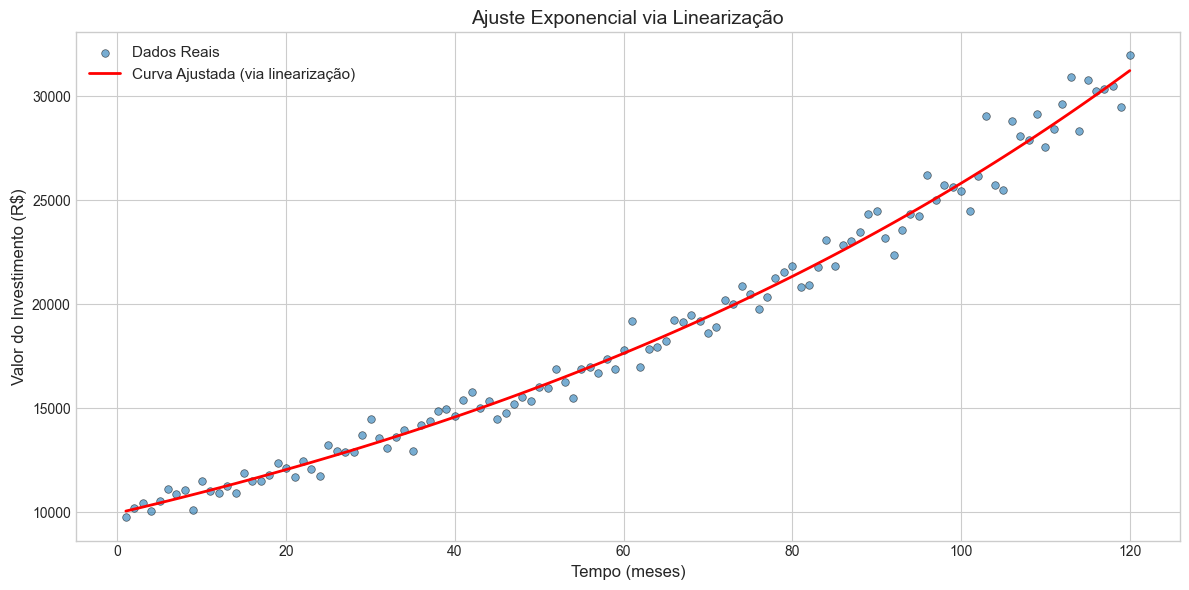

In [11]:
plt.figure(figsize=(12, 6))
plt.scatter(df['meses'], df['valor_investimento'], alpha=0.6, s=30, label='Dados Reais', edgecolors='k', linewidths=0.5)
plt.plot(df['meses'], y_pred_original, color='red', linewidth=2, label='Curva Ajustada (via linearização)')
plt.xlabel('Tempo (meses)', fontsize=12)
plt.ylabel('Valor do Investimento (R$)', fontsize=12)
plt.title('Ajuste Exponencial via Linearização', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 10. Comparação: Com e Sem Linearização

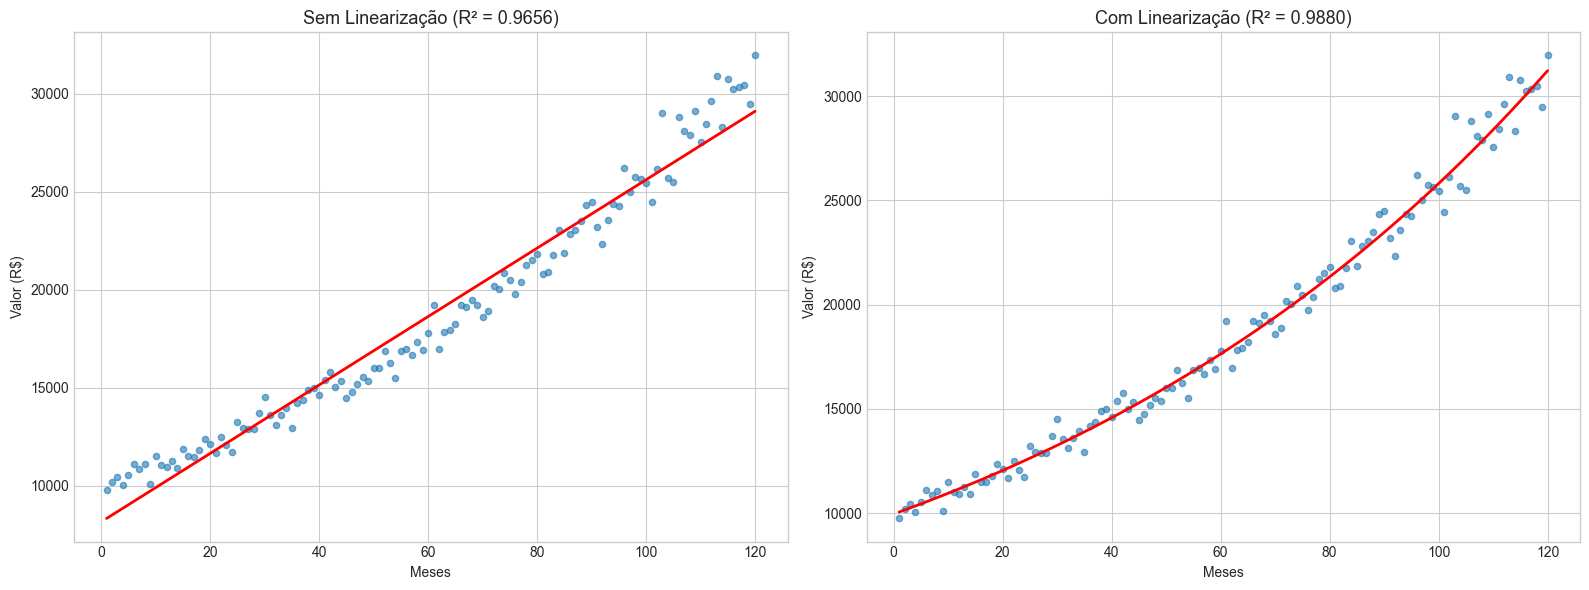

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sem linearização
axes[0].scatter(df['meses'], df['valor_investimento'], alpha=0.6, s=20)
axes[0].plot(df['meses'], y_pred_direto, color='red', linewidth=2)
axes[0].set_title(f'Sem Linearização (R² = {r2_direto:.4f})', fontsize=13)
axes[0].set_xlabel('Meses')
axes[0].set_ylabel('Valor (R$)')

# Com linearização
axes[1].scatter(df['meses'], df['valor_investimento'], alpha=0.6, s=20)
axes[1].plot(df['meses'], y_pred_original, color='red', linewidth=2)
axes[1].set_title(f'Com Linearização (R² = {r2_orig:.4f})', fontsize=13)
axes[1].set_xlabel('Meses')
axes[1].set_ylabel('Valor (R$)')

plt.tight_layout()
plt.show()

## 11. Previsão para Períodos Futuros

In [13]:
meses_futuros = np.array([130, 140, 150, 160, 180, 240]).reshape(-1, 1)
ln_previsoes = modelo_log.predict(meses_futuros)
previsoes_reais = np.exp(ln_previsoes)

print('Previsões para períodos futuros:\n')
for m, v in zip(meses_futuros.flatten(), previsoes_reais):
    anos = m / 12
    print(f'  Mês {m:>3d} ({anos:.1f} anos):  R$ {v:>12,.2f}')

Previsões para períodos futuros:

  Mês 130 (10.8 anos):  R$    34,346.28
  Mês 140 (11.7 anos):  R$    37,777.06
  Mês 150 (12.5 anos):  R$    41,550.54
  Mês 160 (13.3 anos):  R$    45,700.94
  Mês 180 (15.0 anos):  R$    55,286.87
  Mês 240 (20.0 anos):  R$    97,884.21


/Users/fernando.come/Documents/Alura/Regressão_Linear/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
